# 05 – Grundlastanalyse (Hausverbrauch)

Ziel: Die **Grundlast** (minimaler Hausverbrauch) schätzen,  
um aus der prognostizierten PV-Produktion die **verfügbare Überschuss-Energie** zu berechnen:

```
Verfügbare Energie = PV-Prognose − Grundlast
```

Fragen:
1. Wie hoch ist die typische Grundlast (nach Stunde × Wochentag)?
2. Gibt es saisonale Unterschiede?
3. Wie viel Überschuss bleibt typischerweise nach Grundlastabzug?

## 0 · Setup

In [18]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.preprocessing import load_pv_data
from src.data.splitting import time_series_split, split_summary
from src.features.feature_engineering import add_time_features

TARGET_PV   = "Solarproduktion"
TARGET_LOAD = "Hausverbrauch"
RESULTS_DIR = Path("../results/05_grundlast")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1 · Hausverbrauch laden & visualisieren

Zeitraum: 2022-02-07 – 2025-06-16
Datenpunkte: 117,636  (15-min-Auflösung)


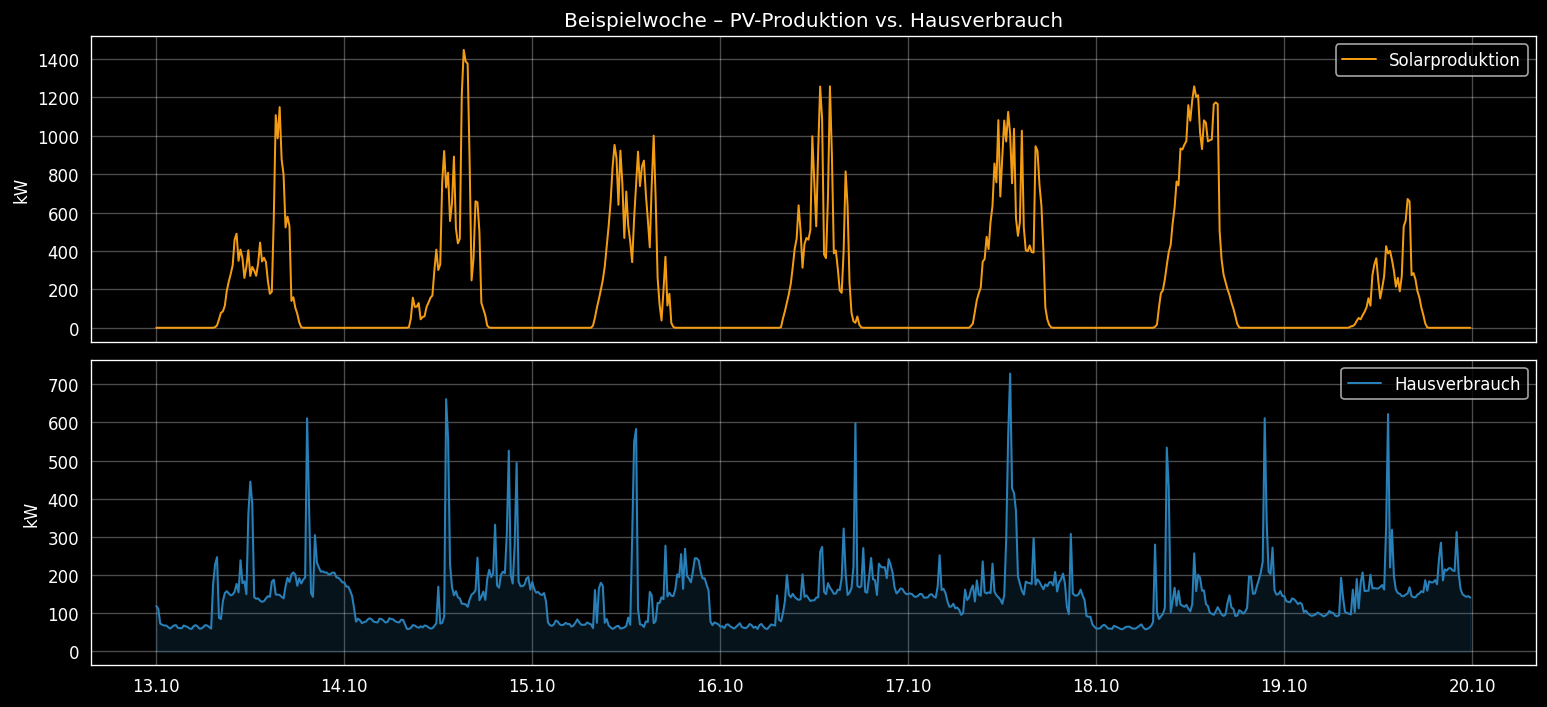


Hausverbrauch – Übersicht:
count    117636.00
mean        175.40
std         167.82
min           0.00
25%          82.00
50%         136.00
75%         201.00
max        4680.00
Name: Hausverbrauch, dtype: float64


In [19]:
df = load_pv_data()
df = add_time_features(df)
print(f"Zeitraum: {df['timestamp'].min().date()} – {df['timestamp'].max().date()}")
print(f"Datenpunkte: {len(df):,}  (15-min-Auflösung)")

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# 7-Tage-Beispiel
start = df["timestamp"].iloc[len(df) // 2].floor("D")
mask  = (df["timestamp"] >= start) & (df["timestamp"] < start + pd.Timedelta(days=7))
sub   = df[mask].set_index("timestamp")

axes[0].plot(sub.index, sub[TARGET_PV],   color="#f39c12", linewidth=1.2, label="Solarproduktion")
axes[0].set_ylabel("kW"); axes[0].legend()
axes[0].set_title("Beispielwoche – PV-Produktion vs. Hausverbrauch")

axes[1].plot(sub.index, sub[TARGET_LOAD], color="#2980b9", linewidth=1.2, label="Hausverbrauch")
axes[1].fill_between(sub.index, 0, sub[TARGET_LOAD], alpha=0.15, color="#2980b9")
axes[1].set_ylabel("kW"); axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
axes[1].xaxis.set_major_locator(mdates.DayLocator())

plt.tight_layout()
plt.show()

print(f"\nHausverbrauch – Übersicht:")
print(df[TARGET_LOAD].describe().round(2))

### Beispieltag (Sommer) – PV-Produktion vs. Grundlast-Profil

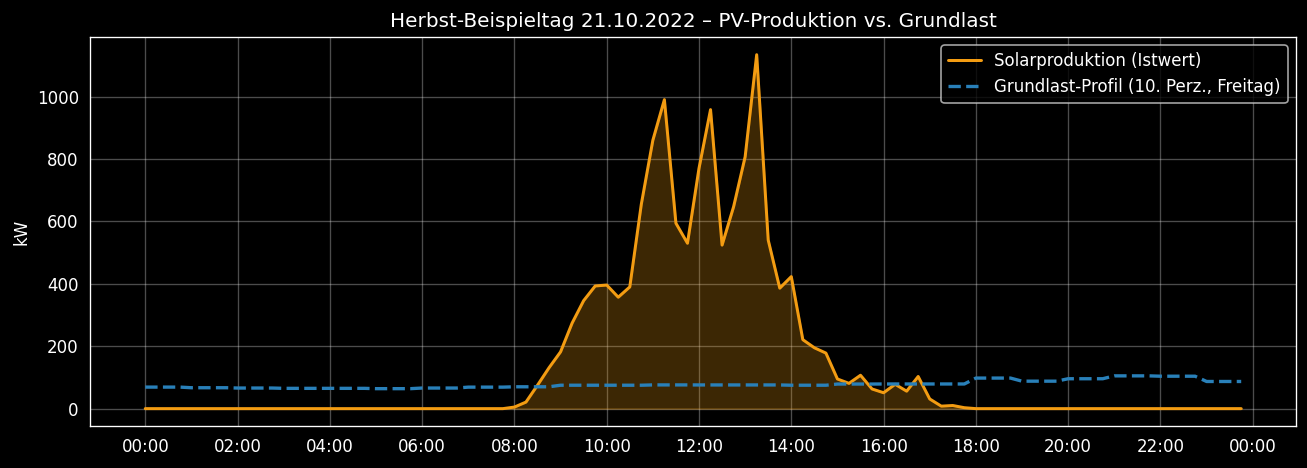

In [20]:
# Herbst-Beispieltag: 21.10.2022 – einzelne PV-Spitze ~3h um die Mittagszeit
# (manuell ausgewählt: ein Block über 500 kW, Peak ~13:15 Uhr)
day_start = pd.Timestamp("2022-10-21")
day_mask = (df["timestamp"] >= day_start) & (df["timestamp"] < day_start + pd.Timedelta(days=1))
day = df[day_mask].copy()

# Grundlast-Profil für den Wochentag dieses Tages (Freitag = 4)
dow = day_start.dayofweek
grundlast_day = grundlast[grundlast["day_of_week"] == dow].set_index("hour")["grundlast"]
day["grundlast"] = day["hour"].map(grundlast_day)

fig, ax = plt.subplots(figsize=(11, 4))

ax.fill_between(day["timestamp"], 0, day[TARGET_PV], alpha=0.25, color="#f39c12")
ax.plot(day["timestamp"], day[TARGET_PV], color="#f39c12", linewidth=1.8, label="Solarproduktion (Istwert)")
ax.plot(day["timestamp"], day["grundlast"], color="#2980b9", linewidth=2, linestyle="--",
        label=f"Grundlast-Profil ({PERCENTILE}. Perz., Freitag)")

ax.set_title(f"Herbst-Beispieltag {day_start.strftime('%d.%m.%Y')} – PV-Produktion vs. Grundlast", fontsize=12)
ax.set_ylabel("kW")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 2)))
ax.legend()
plt.tight_layout()
plt.show()

## 2 · Grundlast-Definition

> **Grundlast** = Verbrauch, der dauerhaft vorhanden ist (Kühlschrank, Standby, …).  
> Schätzmethode: **10. Perzentil** des Hausverbrauchs pro Stunde × Wochentag.  
> Robuster als Minimum (ignoriert kurzfristige Messfehler / Nullwerte).

In [21]:
# Grundlast = 10. Perzentil des Hausverbrauchs je Stunde × Wochentag
# → robuster gegenüber Ausreißern als Minimum

PERCENTILE = 10  # anpassbar

grundlast = (
    df.groupby(["hour", "day_of_week"])[TARGET_LOAD]
    .quantile(PERCENTILE / 100)
    .rename("grundlast")
    .reset_index()
)

print(f"Grundlast-Schätzer ({PERCENTILE}. Perzentil pro Stunde × Wochentag):")
print(f"  Median: {grundlast['grundlast'].median():.2f} kW")
print(f"  Min:    {grundlast['grundlast'].min():.2f} kW")
print(f"  Max:    {grundlast['grundlast'].max():.2f} kW")

Grundlast-Schätzer (10. Perzentil pro Stunde × Wochentag):
  Median: 74.00 kW
  Min:    63.90 kW
  Max:    123.60 kW


In [ ]:
# Grundlast-Profil auf die Beispielwoche legen
# sub ist aus Abschnitt 1 (7-Tage-Fenster) – hier Grundlast per Timestamp nachschlagen
sub_gl = sub.copy()
sub_gl["grundlast"] = sub_gl.apply(
    lambda r: grundlast.loc[
        (grundlast["hour"] == r["hour"]) & (grundlast["day_of_week"] == r["day_of_week"]),
        "grundlast"
    ].values[0],
    axis=1,
)

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(sub_gl.index, sub_gl[TARGET_LOAD], color="#2980b9", linewidth=1.0,
        alpha=0.6, label="Hausverbrauch (Istwert)")
ax.plot(sub_gl.index, sub_gl["grundlast"], color="#c0392b", linewidth=2,
        linestyle="--", label=f"Grundlast-Profil ({PERCENTILE}. Perz., Std × Wochentag)")
ax.fill_between(sub_gl.index, sub_gl["grundlast"], sub_gl[TARGET_LOAD],
                where=sub_gl[TARGET_LOAD] >= sub_gl["grundlast"],
                alpha=0.12, color="#2980b9", label="Verbrauch über Grundlast")

ax.set_ylabel("kW")
ax.set_title("Beispielwoche – Hausverbrauch vs. Grundlast-Profil (10. Perzentil)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d.%m"))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Wie oft liegt Istwert unter der geschätzten Grundlast?
pct_below = (sub_gl[TARGET_LOAD] < sub_gl["grundlast"]).mean() * 100
print(f"Anteil Zeitschritte, wo Istwert < Grundlast-Schätzer: {pct_below:.1f} %  "
      f"(erwartet ~{PERCENTILE} % bei korrekter Schätzung)")

### Entscheidung: Grundlast-Schätzer

**Wir verwenden das 10. Perzentil des Hausverbrauchs pro Stunde × Wochentag.**

Begründung:
- Die gestrichelte Linie im Plot liegt konsistent am unteren Rand des Hausverbrauchs — sie beschreibt den Sockel, der unabhängig von Nutzerverhalten immer vorhanden ist.
- Das 10. Perzentil ist robuster als das Minimum: einzelne Nullwerte oder Messausreißer haben keinen Einfluss.
- Die stündliche × wochentägliche Auflösung bildet typische Muster (z. B. höherer Nachtverbrauch werktags vs. Wochenende) ab, ohne überzufitten.
- Der Anteil der Zeitschritte, bei denen der Istwert unter dem Schätzer liegt, sollte nahe ~10 % sein (Plausibilitätscheck im Plot oben).

**Verwendung im Prognose-Post-Processing:**
```python
verfuegbare_energie = max(0, PV_Prognose − grundlast(hour, day_of_week))
```
Der `max(0, …)` verhindert negative Überschüsse, wenn die PV-Prognose unter der Grundlast liegt.

## 3 · Grundlast nach Stunde und Wochentag

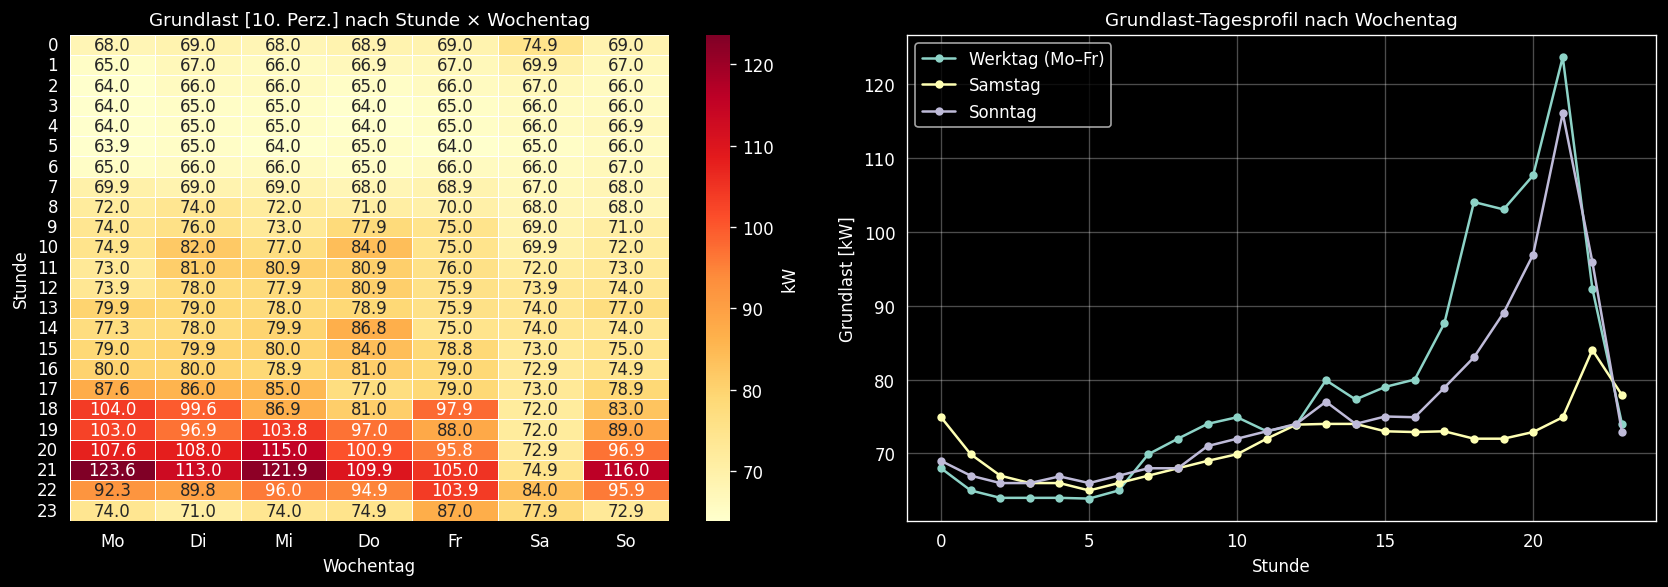

In [22]:
# Heatmap: Grundlast nach Stunde × Wochentag
pivot = grundlast.pivot(index="hour", columns="day_of_week", values="grundlast")
pivot.columns = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    pivot, ax=axes[0], cmap="YlOrRd", annot=True, fmt=".1f",
    linewidths=0.4, cbar_kws={"label": "kW"},
)
axes[0].set_title(f"Grundlast [{PERCENTILE}. Perz.] nach Stunde × Wochentag", fontsize=11)
axes[0].set_xlabel("Wochentag")
axes[0].set_ylabel("Stunde")

# Tagesprofil
for dow, name in [(0, "Werktag (Mo–Fr)"), (5, "Samstag"), (6, "Sonntag")]:
    sub = grundlast[grundlast["day_of_week"] == dow]
    axes[1].plot(sub["hour"], sub["grundlast"], marker="o", markersize=4, label=name)
axes[1].set_title("Grundlast-Tagesprofil nach Wochentag", fontsize=11)
axes[1].set_xlabel("Stunde")
axes[1].set_ylabel("Grundlast [kW]")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4 · Saisonaler Vergleich

/tmp/ipykernel_156006/2843487053.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_season, labels=season_order, patch_artist=True,


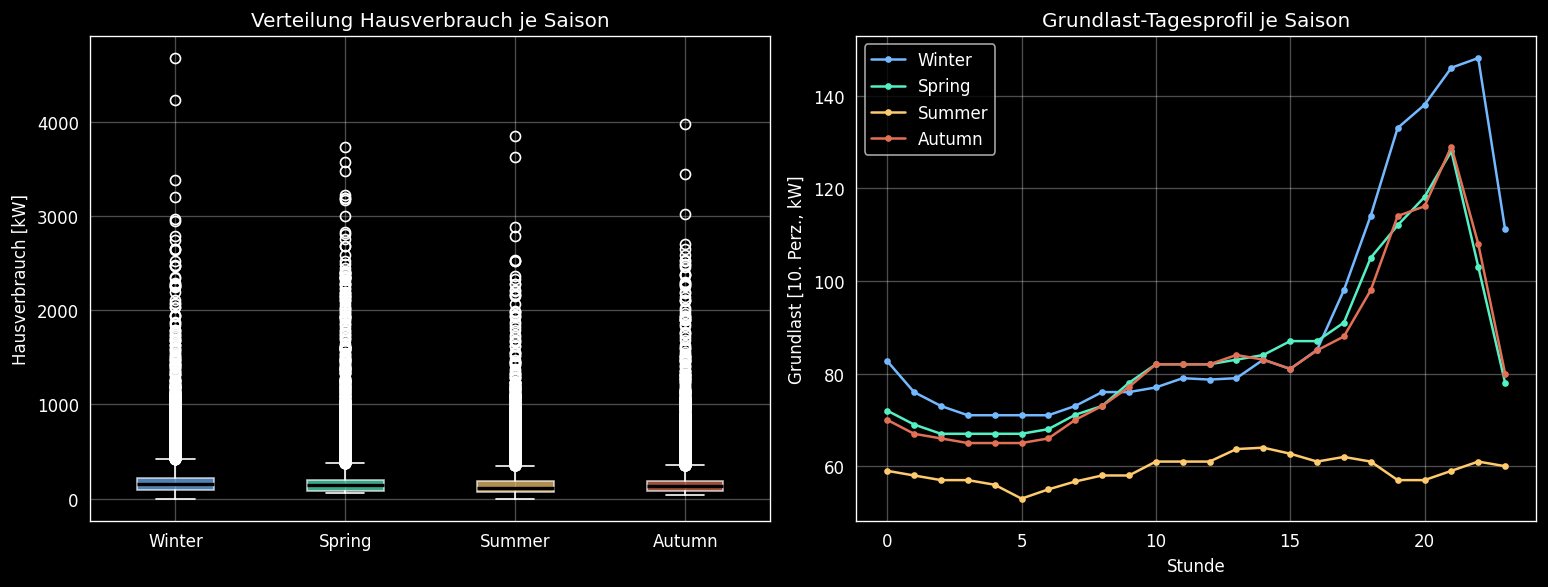

Grundlast-Statistik je Saison:
        Grundlast [kW]
season                
Winter            75.0
Spring            72.0
Summer            59.0
Autumn            71.0


In [23]:
# Saisonaler Vergleich der Grundlast

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Autumn", 10: "Autumn", 11: "Autumn"}

df["season"] = df["timestamp"].dt.month.map(season_map)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = {"Winter": "#74b9ff", "Spring": "#55efc4",
                 "Summer": "#fdcb6e", "Autumn": "#e17055"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box-Plot: Hausverbrauch je Saison
data_by_season = [df[df["season"] == s][TARGET_LOAD].dropna() for s in season_order]
bp = axes[0].boxplot(data_by_season, labels=season_order, patch_artist=True,
                     medianprops={"color": "black", "linewidth": 2})
for patch, season in zip(bp["boxes"], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.7)
axes[0].set_ylabel("Hausverbrauch [kW]")
axes[0].set_title("Verteilung Hausverbrauch je Saison")

# Tagesprofil je Saison (Median)
for season in season_order:
    profile = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_LOAD]
        .quantile(PERCENTILE / 100)
    )
    axes[1].plot(profile.index, profile.values, marker="o", markersize=3,
                 label=season, color=season_colors[season])
axes[1].set_xlabel("Stunde")
axes[1].set_ylabel(f"Grundlast [{PERCENTILE}. Perz., kW]")
axes[1].set_title("Grundlast-Tagesprofil je Saison")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Grundlast-Statistik je Saison:")
print(
    df.groupby("season")[TARGET_LOAD]
    .quantile(PERCENTILE / 100)
    .reindex(season_order)
    .round(2)
    .to_frame("Grundlast [kW]")
)